In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Reach grid

Voxel grid around the shoulder of one 3-DOF leg (the planner's climb leg). Per vertex:
reachable per IK branch, joint angles, knee-to-foot vector. No joint limits.

In [11]:
import time

import jax
import jax.numpy as jnp
import numpy as np
import rerun as rr
import matplotlib.pyplot as plt

from controlkit.se3 import SE3
from controlkit.kinematics import Leg3DOF
import controlkit.rerun_viz as rrv

from lab.gait_graph.planner.climb_model.config import MjModelCfg

In [12]:
cfg = MjModelCfg()
leg = Leg3DOF.from_lengths(jnp.asarray(cfg.leg_lengths))   # limits=None -> full range
reach = float(sum(cfg.leg_lengths))
print("lengths:", cfg.leg_lengths, " reach:", reach)

lengths: (0.05, 0.15, 0.2)  reach: 0.4


## Grid

In [13]:
RES = 0.02   # voxel size (m)

n = int(round(2 * reach / RES)) + 1
axis = jnp.linspace(-reach, reach, n)
X, Y, Z = jnp.meshgrid(axis, axis, axis, indexing="ij")
verts = jnp.stack([X, Y, Z], axis=-1).reshape(-1, 3)        # (n^3, 3), shoulder frame
print(f"{n}^3 = {verts.shape[0]:,} vertices")

41^3 = 68,921 vertices


## IK over the grid

`ik_from_foot` returns all 4 branches (2 yaws x 2 elbows). Knee-to-foot comes from
forward kinematics of each branch: `xpos[-1] - xpos[-2]`.

In [14]:
def _reach_vertex(foot):
    ok, thetas = leg.ik_from_foot(foot)                    # (4,), (4, 3)
    xpos = jax.vmap(leg.forward)(thetas).translation()     # (4, n+1, 3)
    knee_to_foot = xpos[:, -1] - xpos[:, -2]               # (4, 3)
    err = jnp.linalg.norm(xpos[:, -1] - foot, axis=-1)     # (4,) FK check
    return ok, thetas, knee_to_foot, err

reach_grid = jax.jit(jax.vmap(_reach_vertex))

t0 = time.perf_counter(); out = jax.block_until_ready(reach_grid(verts)); t1 = time.perf_counter()
out = jax.block_until_ready(reach_grid(verts)); t2 = time.perf_counter()
print(f"compile+run: {t1 - t0:.2f}s   run: {(t2 - t1) * 1e3:.1f}ms")

ok, thetas, knee_to_foot, err = out
print("ok", ok.shape, " thetas", thetas.shape, " knee_to_foot", knee_to_foot.shape)

compile+run: 0.26s   run: 38.6ms
ok (68921, 4)  thetas (68921, 4, 3)  knee_to_foot (68921, 4, 3)


In [15]:
reachable = ok.any(-1)
print(f"reachable vertices: {int(reachable.sum()):,} / {verts.shape[0]:,} ({float(reachable.mean()):.1%})")
print("branches per vertex:", {int(k): int(v) for k, v in zip(*np.unique(ok.sum(-1), return_counts=True))})
print(f"max FK error on reachable branches: {float(jnp.where(ok, err, 0).max()):.2e} m")

reachable vertices: 30,730 / 68,921 (44.6%)
branches per vertex: {0: 38191, 2: 15479, 4: 15251}
max FK error on reachable branches: 1.21e-04 m


## Size

In [16]:
data = dict(verts=verts, ok=ok, thetas=thetas, knee_to_foot=knee_to_foot)
for k, v in data.items():
    print(f"{k:14s} {str(v.shape):14s} {v.dtype}  {v.nbytes / 1e6:7.3f} MB")
print(f"{'total':14s} {'':14s} {'':7s}  {sum(v.nbytes for v in data.values()) / 1e6:7.3f} MB")

verts          (68921, 3)     float32    0.827 MB
ok             (68921, 4)     bool    0.276 MB
thetas         (68921, 4, 3)  float32    3.308 MB
knee_to_foot   (68921, 4, 3)  float32    3.308 MB
total                                    7.719 MB


## Rerun

(array([38191.,     0.,     0.,     0.,     0., 15479.,     0.,     0.,
            0., 15251.]),
 array([0. , 0.4, 0.8, 1.2, 1.6, 2. , 2.4, 2.8, 3.2, 3.6, 4. ]),
 <BarContainer object of 10 artists>)

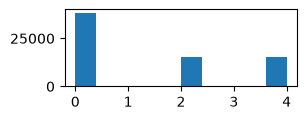

In [31]:
n_branches = np.asarray(ok.sum(-1))   # reachable IK branches per vertex


plt.figure(figsize=(3,1))
plt.hist(n_branches)

In [32]:
rrv.init_viewer(connect=8812)
rrv.set_time(0, timeline="t")


print(f"{n_branches.min(), n_branches.max()}")
rrv.log_points("grid/reachable", np.asarray(verts)[n_branches > 0], values=n_branches[n_branches > 0], radius=0.003)
rrv.log_points("grid/unreachable", np.asarray(verts)[n_branches == 0], radius=0.001, color=(200, 200, 200))

(np.int32(0), np.int32(4))


In [33]:
# Knee-to-foot vectors on the z = 0 slice, first reachable branch per vertex.
sl = (jnp.abs(verts[:, 2]) < 1e-6) & reachable
b = jnp.argmax(ok, axis=-1)
k2f = knee_to_foot[jnp.arange(verts.shape[0]), b]
rr.log("grid/knee_to_foot_z0", rr.Arrows3D(
    origins=np.asarray(verts[sl] - 0.1*k2f[sl]), vectors=0.1*np.asarray(k2f[sl]), radii=0.001))

In [ ]:
# All reachable branches at one vertex.
SHOULDER = SE3.from_te(jnp.zeros(3), jnp.zeros(3))
i = int(jnp.argmin(jnp.linalg.norm(verts - jnp.array([0.25, 0.1, -0.1]), axis=-1)))
print("vertex", verts[i], " ok", ok[i])
for j in range(1):
    if ok[i, j]:
        rrv.log_leg(f"legs/b{j}", leg, SHOULDER, thetas[i, j])

vertex [ 0.24000002  0.10000001 -0.09999999]  ok [ True  True  True  True]


2026-10-08T16:54:13.141432Z ERROR re_grpc_client::write: Write messages call failed: transport error
